In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Si tienes GPU disponible:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


ImportError: cannot import name 'get_config' from 'sklearn' (unknown location)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.81MB/s]


Tamaño train: 4000  val: 1000  test: 10000


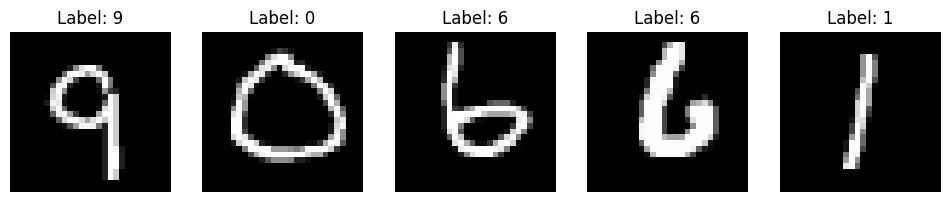

In [2]:
# Escoge MNIST, FashionMNIST o CIFAR10 cambiando esta línea:
DatasetClass = datasets.MNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descarga y split
full_train = DatasetClass(root='data', train=True, download=True, transform=transform)
test_data  = DatasetClass(root='data', train=False, download=True, transform=transform)

# Toma solo un subset pequeño para debug (opcional)
subset_total = 5000
train_len = int(0.8 * subset_total)
val_len   = subset_total - train_len
subset, _  = random_split(full_train, [subset_total, len(full_train)-subset_total])
train_ds, val_ds = random_split(subset, [train_len, val_len])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_data, batch_size=64)

print("Tamaño train:", len(train_ds), " val:", len(val_ds), " test:", len(test_data))

# Visualizar ejemplos
examples = next(iter(train_loader))
imgs, labels = examples
fig, axes = plt.subplots(1,5, figsize=(12,3))
for i in range(5):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')


In [1]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv2D(in_channels, out_channels, kernel_size, stride=1, padding=0)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 16 filtros 3×3
        self.pool  = nn.MaxPool2d(2, 2)                         # reduce a la mitad
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(32*7*7, 128)  # asumiendo input 28×28→pool→14×14→pool→7×7
        self.drop  = nn.Dropout(0.25)
        self.fc2   = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 32*7*7)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)


NameError: name 'nn' is not defined

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

train_losses, val_losses = [], []

for epoch in range(1, epochs+1):
    # --- Train ---
    model.train()
    running_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))

    # --- Validation ---
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, lbls).item()
            preds = outputs.argmax(dim=1)
            correct += (preds == lbls).sum().item()
    val_losses.append(val_loss/len(val_loader))
    val_acc = correct/len(val_ds)

    print(f"Epoch {epoch}/{epochs}  train_loss: {train_losses[-1]:.4f}  val_loss: {val_losses[-1]:.4f}  val_acc: {val_acc:.4f}")


Epoch 1/10  train_loss: 1.1057  val_loss: 0.4151  val_acc: 0.8750
Epoch 2/10  train_loss: 0.3098  val_loss: 0.2595  val_acc: 0.9250
Epoch 3/10  train_loss: 0.2020  val_loss: 0.2252  val_acc: 0.9280
Epoch 4/10  train_loss: 0.1354  val_loss: 0.1751  val_acc: 0.9440
Epoch 5/10  train_loss: 0.1085  val_loss: 0.1732  val_acc: 0.9480
Epoch 6/10  train_loss: 0.0865  val_loss: 0.1626  val_acc: 0.9460
Epoch 7/10  train_loss: 0.0714  val_loss: 0.1363  val_acc: 0.9590
Epoch 8/10  train_loss: 0.0586  val_loss: 0.1343  val_acc: 0.9630
Epoch 9/10  train_loss: 0.0485  val_loss: 0.1330  val_acc: 0.9650
Epoch 10/10  train_loss: 0.0437  val_loss: 0.1379  val_acc: 0.9580


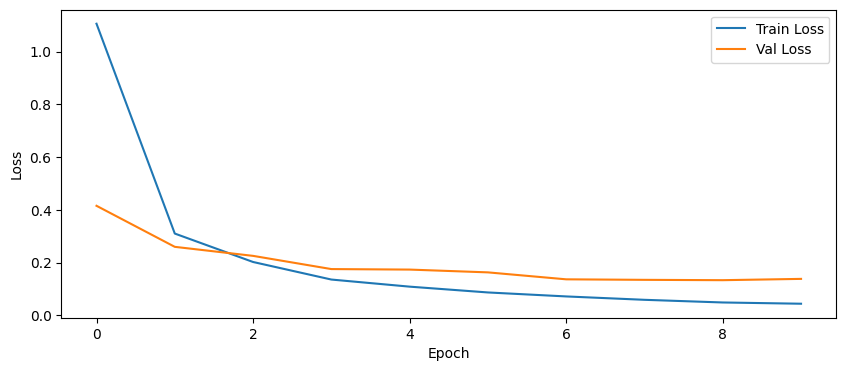

In [5]:
# Graficar curvas
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [7]:
# Predicción sobre test set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.tolist())

# Reporte de métricas
print(classification_report(all_labels, all_preds, zero_division=0))




              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.99      0.97      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.96      0.98       958
           7       0.98      0.95      0.97      1028
           8       0.93      0.97      0.95       974
           9       0.95      0.98      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



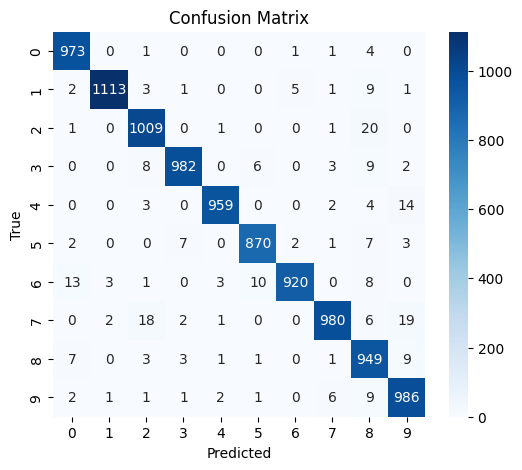

In [8]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



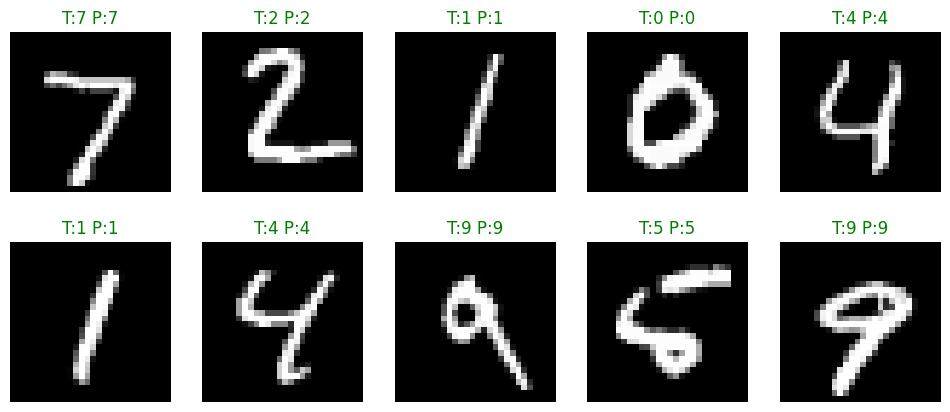

In [9]:
# Ejemplos correctos e incorrectos
fig, axes = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.flatten()):
    img = test_data[i][0]
    true_lbl = test_data[i][1]
    pred_lbl = all_preds[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"T:{true_lbl} P:{pred_lbl}",
                 color=('green' if true_lbl==pred_lbl else 'red'))
    ax.axis('off')

In [10]:
# 7.1 Agregar Dropout extra
model.drop = nn.Dropout(0.5)

# 7.2 Cambiar kernel de la primera capa
model.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)

# 7.3 Guardar y cargar modelo
torch.save(model.state_dict(), "simple_cnn.pth")
# Para cargar luego:
# model = SimpleCNN().to(device)
# model.load_state_dict(torch.load("simple_cnn.pth"))
# model.eval()
